# Cross-platform transfer and cohort-size stability Notebook

**Purpose.** Analyses 3 and 4 of the report: whether a fragmentomic model trained on sWGS features still works on capture features from the same samples, and how stable the estimated fragmentomic contribution is at smaller cohort sizes.

**Inputs:** `results/features_wgs.csv` and `results/features_capture.csv` from notebook 01; `results/table_4_1_performance.csv` from notebook 02 (for the null-model line in Figure 4.5).
**Outputs:** `results/transfer.csv`, `results/stability.csv`, the Table 4.5–4.6 CSV files, and Figures 4.5–4.6.

In [1]:
# ---- Setup: imports, run mode and folders --------------------------------------------
import os, time, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.exceptions import ConvergenceWarning

import common, engine
from common import load, feature_matrix, sha256, logit, expit, LENGTHS, EXPECTED_SHA256
from engine import splits, fit_predict, pooled_metrics, nb_corrected_t

# Elastic-net fits at the weakest penalties on the path can stop before full convergence;
# this is expected and does not affect the selected model, so these warnings are hidden.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
# openpyxl warns about an Excel extension it cannot read; it does not affect the data.
warnings.filterwarnings("ignore", message="Unknown extension is not supported")

# Output folders: tables and cached results in results/, figures in figures/
RES = Path("results")
FIG = Path("figures")
RES.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
DATA = Path("data/elife-71569-supp1-v2.xlsx")

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
print("Repeats:", engine.N_REPEATS, "| random-forest trees:", engine.RF_TREES)

C:\Users\5320\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Repeats: 20 | random-forest trees: 500


In [2]:
W = pd.read_csv(RES / "features_wgs.csv")
W = W[W.vaf_ctdna.notna()].reset_index(drop=True)
Cf = pd.read_csv(RES / "features_capture.csv")
y = W.vaf_ctdna.to_numpy()
frag = list(Cf.columns)                        # the same 14 features, in the same order
XW, XCp = W[frag].to_numpy(), Cf[frag].to_numpy()
S = splits(len(y))
print(len(y), "paired samples |", len(S), "splits")

86 paired samples | 100 splits


## 1. Cross-platform transfer (Analysis 3, Table 4.5)

Only the fragmentomic arm can be tested, because ichorCNA exists only for sWGS. All four conditions use the same splits, so no test sample's features or label are ever used in training. In the standardised condition, each platform's features are centred and scaled with its own training-fold samples: this uses unlabelled target-platform data, but no outcomes.

In [3]:
from sklearn.preprocessing import StandardScaler
conds = ["sWGS -> sWGS", "sWGS -> capture (raw)", "sWGS -> capture (standardised per platform)", "capture -> capture"]
cache = RES / "transfer.csv"
if cache.exists():
    T = pd.read_csv(cache)
    print("Loaded cached results from", cache)
else:
    rows = []
    for model in ["EN", "RF"]:
        P = {cn: np.full((engine.N_REPEATS, len(y)), np.nan) for cn in conds}
        for s, (tr, te) in enumerate(S):
            r = s // engine.N_SPLITS
            (a, b), _ = fit_predict(model, XW[tr], y[tr], [XW[te], XCp[te]], seed=s)
            P[conds[0]][r, te], P[conds[1]][r, te] = a, b
            sw, sc = StandardScaler().fit(XW[tr]), StandardScaler().fit(XCp[tr])
            (c2,), _ = fit_predict(model, sw.transform(XW[tr]), y[tr], [sc.transform(XCp[te])], seed=s)
            P[conds[2]][r, te] = c2
            (d2,), _ = fit_predict(model, XCp[tr], y[tr], [XCp[te]], seed=s)
            P[conds[3]][r, te] = d2
        for cn, M in P.items():
            for r in range(engine.N_REPEATS):
                rows.append(dict(model=model, cond=cn, rep=r, **pooled_metrics(y, M[r])))
        print(model, "done")
    T = pd.DataFrame(rows); T.to_csv(cache, index=False)

t35 = T.groupby(["model", "cond"], sort=False)[["rmse", "spearman", "cal_slope", "citl"]].median()
t35.to_csv(RES / "table_4_5_transfer.csv")
display(t35.round(3))

# Why naive transfer fails: some features change their relationship with the outcome
print("Median length vs VAF-based fraction - sWGS rho = %.2f, capture rho = %.2f"
      % (spearmanr(W.median_length, y)[0], spearmanr(Cf.median_length, y)[0]))

EN done
RF done


rmse  spearman  cal_slope  \
model cond                                                                      
EN    sWGS -> sWGS                                 0.172     0.731      0.928   
      sWGS -> capture (raw)                        0.391     0.531      0.411   
      sWGS -> capture (standardised per platform)  0.203     0.632      0.811   
      capture -> capture                           0.156     0.790      0.965   
RF    sWGS -> sWGS                                 0.178     0.749      1.035   
      sWGS -> capture (raw)                        0.286     0.125      0.472   
      sWGS -> capture (standardised per platform)  0.195     0.656      1.182   
      capture -> capture                           0.168     0.752      1.065   

                                                    citl  
model cond                                                
EN    sWGS -> sWGS                                 0.029  
      sWGS -> capture (raw)                       -0.238  
      sWGS -> capture (standardised per platform)  0.040  
      capture -> capture                           0.028  
RF    sWGS -> sWGS                                 0.037  
      sWGS -> capture (raw)                       -0.118  
      sWGS -> capture (standardised per platform)  0.030  
      capture -> capture                           0.035

Median length vs VAF-based fraction - sWGS rho = -0.25, capture rho = 0.37


## 2. Cohort-size stability (Analysis 4, Table 4.6)

Subsets of each size are drawn from the 86 samples, and the RMSE difference between Arms C and B (elastic net) is estimated in each. Because subsets overlap, this describes instability rather than independent replication. At n = 86 every run uses the same samples, and only the cross-validation partition changes: this row shows how misleading the spread across repeats can be.

In [4]:
from sklearn.model_selection import RepeatedKFold
XB = logit(W[["ichorCNA"]].to_numpy())
XCc = np.column_stack([W[frag].to_numpy(), XB])
sizes = [20, 30, 40, 50, 60, 70, 86]
n_draws = 50
cache = RES / "stability.csv"
if cache.exists():
    Sdf = pd.read_csv(cache)
    print("Loaded cached results from", cache)
else:
    rows = []
    for n in sizes:
        for dnum in range(n_draws):
            idx = (np.random.default_rng(100 * n + dnum).choice(len(y), n, replace=False)
                   if n < len(y) else np.arange(len(y)))
            yy, res = y[idx], {}
            for arm, X in [("B", XB[idx]), ("C", XCc[idx])]:
                P = np.zeros((2, n))
                cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=1000 * n + dnum)
                for s, (tr, te) in enumerate(cv.split(yy)):
                    (p,), _ = fit_predict("EN", X[tr], yy[tr], [X[te]], seed=s)
                    P[s // 5, te] = p
                ms = [pooled_metrics(yy, P[r]) for r in range(2)]
                res[arm] = {k: np.mean([m_[k] for m_ in ms]) for k in ms[0]}
            rows.append(dict(n=n, draw=dnum, rmse_B=res["B"]["rmse"], rmse_C=res["C"]["rmse"],
                             rho_B=res["B"]["spearman"], rho_C=res["C"]["spearman"], slope_C=res["C"]["cal_slope"]))
        print("n =", n, "done")
    Sdf = pd.DataFrame(rows); Sdf["dRMSE"] = Sdf.rmse_C - Sdf.rmse_B; Sdf.to_csv(cache, index=False)

q = lambda s: f"{s.median():+.3f} ({s.quantile(.05):+.3f} to {s.quantile(.95):+.3f})"
t36 = Sdf.groupby("n").agg(median_difference_p5_p95=("dRMSE", q),
                           C_appears_better=("dRMSE", lambda s: f"{(s < 0).mean():.0%}"),
                           C_worse_by_more_than_0_02=("dRMSE", lambda s: f"{(s > 0.02).mean():.0%}"))
t36.to_csv(RES / "table_4_6_stability.csv")
display(t36)

n = 20 done
n = 30 done
n = 40 done
n = 50 done
n = 60 done
n = 70 done
n = 86 done


,median_difference_p5_p95,C_appears_better,C_worse_by_more_than_0_02
n,,,
20,+0.011 (-0.036 to +0.056),28%,36%
30,+0.002 (-0.027 to +0.026),48%,14%
40,-0.000 (-0.026 to +0.023),50%,10%
50,-0.002 (-0.019 to +0.021),54%,6%
60,-0.003 (-0.017 to +0.013),66%,0%
70,-0.004 (-0.017 to +0.005),72%,0%
86,-0.006 (-0.010 to -0.001),96%,0%


## 3. Figures 4.5–4.6

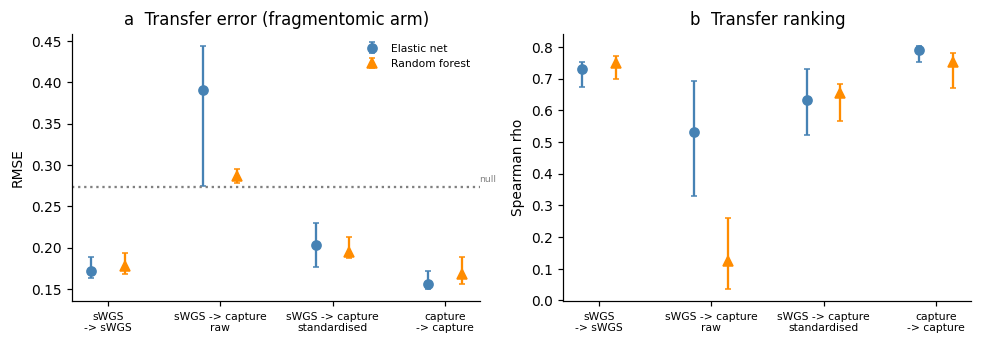

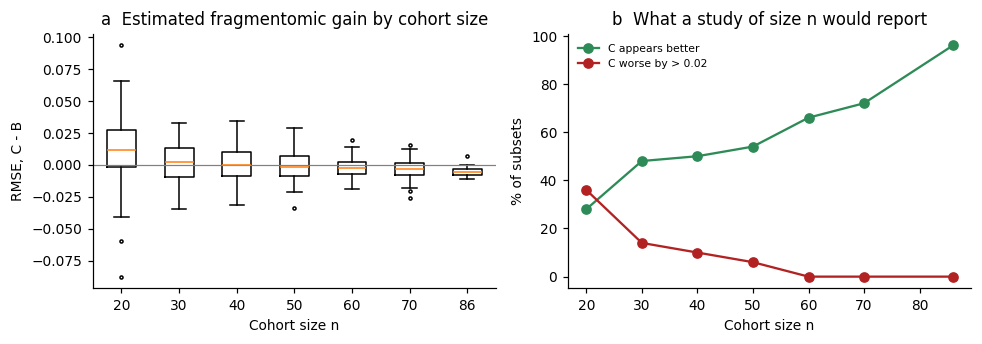

In [5]:
null_path = RES / "table_4_1_performance.csv"
null_rmse = pd.read_csv(null_path).query("arm == 'Null'").rmse.iloc[0] if null_path.exists() else None

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
short = ["sWGS\n-> sWGS", "sWGS -> capture\nraw", "sWGS -> capture\nstandardised", "capture\n-> capture"]
for k, met in enumerate(["rmse", "spearman"]):
    for j, (model, name) in enumerate([("EN", "Elastic net"), ("RF", "Random forest")]):
        for i, cn in enumerate(conds):
            v = T[(T.model == model) & (T.cond == cn)][met]; x = i + (j - .5) * .3
            ax[k].errorbar(x, v.median(), yerr=[[v.median() - v.quantile(.025)], [v.quantile(.975) - v.median()]],
                           fmt="o" if model == "EN" else "^", c="steelblue" if model == "EN" else "darkorange",
                           capsize=2, label=name if i == 0 else None)
    ax[k].set_xticks(range(4)); ax[k].set_xticklabels(short, fontsize=7)
if null_rmse is not None:
    ax[0].axhline(null_rmse, ls=":", c="grey"); ax[0].text(3.3, null_rmse + .006, "null", fontsize=6, c="grey")
ax[0].set(ylabel="RMSE", title="a  Transfer error (fragmentomic arm)")
ax[1].set(ylabel="Spearman rho", title="b  Transfer ranking"); ax[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "fig4_5_transfer.png", dpi=150); plt.show()

ns = sorted(Sdf.n.unique())
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].boxplot([Sdf[Sdf.n == n].dRMSE for n in ns], tick_labels=ns, showfliers=True, flierprops=dict(markersize=2))
ax[0].axhline(0, c="grey", lw=.8)
ax[0].set(xlabel="Cohort size n", ylabel="RMSE, C - B", title="a  Estimated fragmentomic gain by cohort size")
ax[1].plot(ns, [(Sdf[Sdf.n == n].dRMSE < 0).mean() * 100 for n in ns], marker="o", c="seagreen", label="C appears better")
ax[1].plot(ns, [(Sdf[Sdf.n == n].dRMSE > 0.02).mean() * 100 for n in ns], marker="o", c="firebrick", label="C worse by > 0.02")
ax[1].set(xlabel="Cohort size n", ylabel="% of subsets", title="b  What a study of size n would report")
ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "fig4_6_stability.png", dpi=150); plt.show()